### Problem-01: Write a  Python program using perceptron net for AND function with bipolar inputs and targets. The convergence curves and the decision boundary lines are also shown.

Bipolar AND Perceptron
------------------------------
Learning rate: 1.0
Final weights: [1. 1.]
Final bias: -1.0
Epochs to converge: 2
Errors per epoch: [1, 0]

Final Predictions:
Input [-1 -1] -> Target = -1, Output = -1
Input [-1  1] -> Target = -1, Output = -1
Input [ 1 -1] -> Target = -1, Output = -1
Input [1 1] -> Target = 1, Output = 1


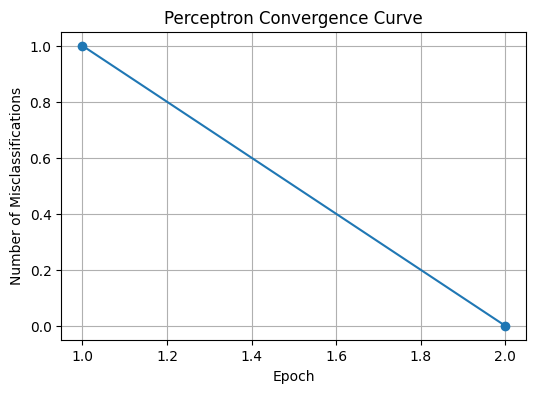

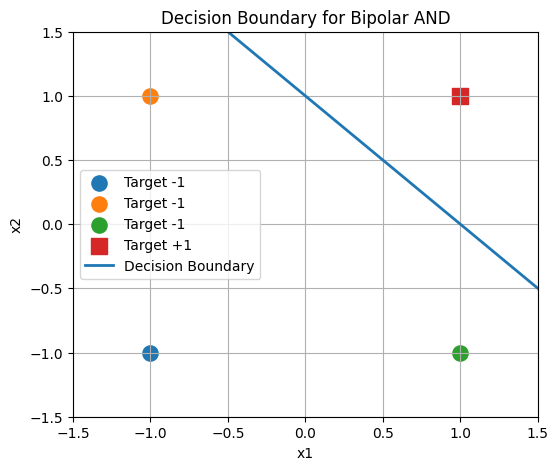

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bipolar AND function
# Inputs: (-1,-1), (-1,1), (1,-1), (1,1)
X = np.array([
    [-1, -1],
    [-1,  1],
    [ 1, -1],
    [ 1,  1]
], dtype=float)

# Bipolar AND targets
T = np.array([-1, -1, -1, 1], dtype=float)

# Parameters
learning_rate = 1.0
weights = np.array([0.0, 0.0])
bias = 0.0

errors_per_epoch = []

# Perceptron training
for epoch in range(1, 101):
    errors = 0

    for x, target in zip(X, T):

        # Calculate net input
        net = np.dot(weights, x) + bias

        # Bipolar activation function
        output = 1 if net >= 0 else -1

        # Update weights and bias if prediction is wrong
        if output != target:
            weights += learning_rate * target * x
            bias += learning_rate * target
            errors += 1

    errors_per_epoch.append(errors)

    # Stop when all patterns are classified correctly
    if errors == 0:
        break

# Display results
print("Bipolar AND Perceptron")
print("-" * 30)
print("Learning rate:", learning_rate)
print("Final weights:", weights)
print("Final bias:", bias)
print("Epochs to converge:", epoch)
print("Errors per epoch:", errors_per_epoch)

print("\nFinal Predictions:")
for x, target in zip(X, T):
    net = np.dot(weights, x) + bias
    output = 1 if net >= 0 else -1
    print(f"Input {x.astype(int)} -> Target = {int(target)}, Output = {output}")

# -------------------------------
# Plot convergence curve
# -------------------------------
plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(errors_per_epoch) + 1),
    errors_per_epoch,
    marker='o'
)

plt.title("Perceptron Convergence Curve")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.grid(True)
plt.show()

# -------------------------------
# Plot decision boundary
# -------------------------------
plt.figure(figsize=(6, 5))

# Plot input points
for x, target in zip(X, T):
    if target == -1:
        plt.scatter(x[0], x[1], marker='o', s=120,
                    label="Target -1")
    else:
        plt.scatter(x[0], x[1], marker='s', s=120,
                    label="Target +1")

# Decision boundary:
# w1*x1 + w2*x2 + bias = 0
x1 = np.linspace(-1.5, 1.5, 200)
x2 = -(weights[0] * x1 + bias) / weights[1]

plt.plot(x1, x2, linewidth=2, label="Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary for Bipolar AND")
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.show()

### Problem-02: Implement the SGD Method using Delta learning rule for following input-target sets.
X_input = [0 0 1; 0 1 1; 1 0 1; 1 1 1], D_target = [0; 0; 1; 1]


SGD Using Delta Learning Rule
--------------------------------
Learning Rate: 0.1
Number of Epochs: 100

Final Weights:
w1 = 0.999684
w2 = -0.000318
Bias = 0.000428

Final Predictions:
--------------------------------
Input = [0 0]  Target = 0  Output = 0.000428
Input = [0 1]  Target = 0  Output = 0.00011
Input = [1 0]  Target = 1  Output = 1.000112
Input = [1 1]  Target = 1  Output = 0.999794

Final Total Squared Error: 3.1e-07


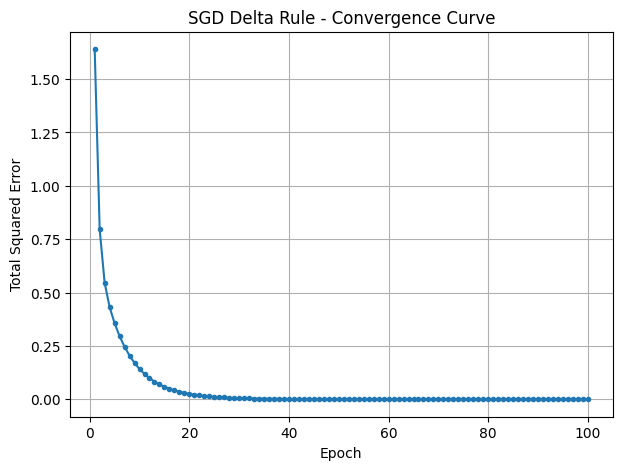

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Target values
D = np.array([0, 0, 1, 1], dtype=float)

# Learning rate
eta = 0.1

# Initialize weights and bias
weights = np.array([0.0, 0.0])
bias = 0.0

# Number of epochs
max_epochs = 100

# Store error for convergence curve
error_history = []

# ------------------------------------------------
# Stochastic Gradient Descent using Delta Rule
# ------------------------------------------------
for epoch in range(max_epochs):

    total_error = 0

    # Process one training sample at a time
    for x, d in zip(X, D):

        # Calculate output
        y = np.dot(weights, x) + bias

        # Calculate error
        error = d - y

        # Delta rule weight update
        weights = weights + eta * error * x

        # Bias update
        bias = bias + eta * error

        # Squared error
        total_error += error ** 2

    # Store total error
    error_history.append(total_error)

# ------------------------------------------------
# Display final results
# ------------------------------------------------

print("SGD Using Delta Learning Rule")
print("--------------------------------")
print("Learning Rate:", eta)
print("Number of Epochs:", max_epochs)

print("\nFinal Weights:")
print("w1 =", round(weights[0], 6))
print("w2 =", round(weights[1], 6))
print("Bias =", round(bias, 6))

print("\nFinal Predictions:")
print("--------------------------------")

for x, d in zip(X, D):

    y = np.dot(weights, x) + bias

    print(
        "Input =", x.astype(int),
        " Target =", int(d),
        " Output =", round(y, 6)
    )

print("\nFinal Total Squared Error:",
      round(error_history[-1], 8))


# ------------------------------------------------
# Convergence Curve
# ------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, max_epochs + 1),
    error_history,
    marker='o',
    markersize=3
)

plt.xlabel("Epoch")
plt.ylabel("Total Squared Error")
plt.title("SGD Delta Rule - Convergence Curve")
plt.grid(True)

plt.show()

### Problem 03: Compare the performance of SGD and the Batch method using the delta learning rule.

COMPARISON OF SGD AND BATCH DELTA LEARNING

SGD Method
------------------------------
w1 = 0.999684
w2 = -0.000318
Bias = 0.000428
Final Error = 3.1e-07

Batch Method
------------------------------
w1 = 0.999538
w2 = -0.000436
Bias = 0.000532
Final Error = 4.9e-07


SGD Predictions
------------------------------
Input = [0 0] Target = 0 Output = 0.000428
Input = [0 1] Target = 0 Output = 0.00011
Input = [1 0] Target = 1 Output = 1.000112
Input = [1 1] Target = 1 Output = 0.999794

Batch Predictions
------------------------------
Input = [0 0] Target = 0 Output = 0.000532
Input = [0 1] Target = 0 Output = 9.7e-05
Input = [1 0] Target = 1 Output = 1.00007
Input = [1 1] Target = 1 Output = 0.999635


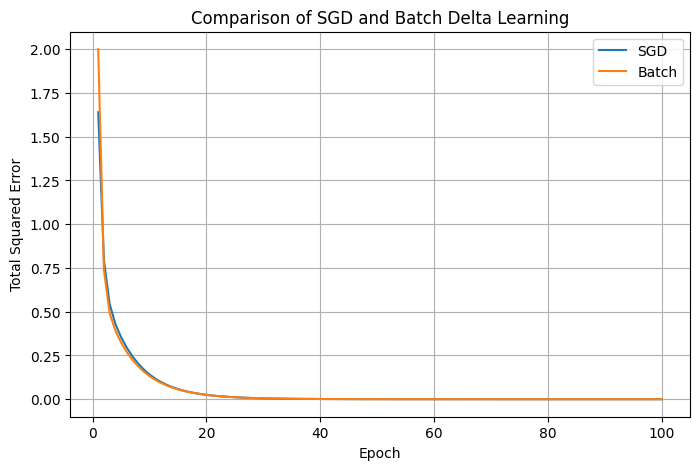

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Input and Target
# ------------------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

D = np.array([0, 0, 1, 1], dtype=float)

# Learning rate
eta = 0.1

# Number of epochs
epochs = 100


# =================================================
# 1. SGD USING DELTA RULE
# =================================================

weights_sgd = np.array([0.0, 0.0])
bias_sgd = 0.0

sgd_error_history = []

for epoch in range(epochs):

    total_error = 0

    # Update after every sample
    for x, d in zip(X, D):

        # Calculate output
        y = np.dot(weights_sgd, x) + bias_sgd

        # Calculate error
        error = d - y

        # Delta rule update
        weights_sgd = weights_sgd + eta * error * x
        bias_sgd = bias_sgd + eta * error

        total_error += error ** 2

    sgd_error_history.append(total_error)


# =================================================
# 2. BATCH GRADIENT DESCENT USING DELTA RULE
# =================================================

weights_batch = np.array([0.0, 0.0])
bias_batch = 0.0

batch_error_history = []

for epoch in range(epochs):

    # Calculate outputs for all samples
    y = np.dot(X, weights_batch) + bias_batch

    # Calculate errors
    errors = D - y

    # Calculate total squared error
    total_error = np.sum(errors ** 2)

    # Store error
    batch_error_history.append(total_error)

    # Batch Delta Rule
    weights_batch = weights_batch + eta * np.dot(X.T, errors)
    bias_batch = bias_batch + eta * np.sum(errors)


# =================================================
# Display Results
# =================================================

print("=" * 55)
print("COMPARISON OF SGD AND BATCH DELTA LEARNING")
print("=" * 55)

print("\nSGD Method")
print("-" * 30)
print("w1 =", round(weights_sgd[0], 6))
print("w2 =", round(weights_sgd[1], 6))
print("Bias =", round(bias_sgd, 6))
print("Final Error =", round(sgd_error_history[-1], 8))


print("\nBatch Method")
print("-" * 30)
print("w1 =", round(weights_batch[0], 6))
print("w2 =", round(weights_batch[1], 6))
print("Bias =", round(bias_batch, 6))
print("Final Error =", round(batch_error_history[-1], 8))


# =================================================
# Predictions
# =================================================

print("\n\nSGD Predictions")
print("-" * 30)

for x, d in zip(X, D):
    y = np.dot(weights_sgd, x) + bias_sgd

    print(
        "Input =", x.astype(int),
        "Target =", int(d),
        "Output =", round(y, 6)
    )


print("\nBatch Predictions")
print("-" * 30)

for x, d in zip(X, D):
    y = np.dot(weights_batch, x) + bias_batch

    print(
        "Input =", x.astype(int),
        "Target =", int(d),
        "Output =", round(y, 6)
    )


# =================================================
# Convergence Curve
# =================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    sgd_error_history,
    label="SGD"
)

plt.plot(
    range(1, epochs + 1),
    batch_error_history,
    label="Batch"
)

plt.xlabel("Epoch")
plt.ylabel("Total Squared Error")
plt.title("Comparison of SGD and Batch Delta Learning")
plt.legend()
plt.grid(True)

plt.show()

### Problem 04: Write a  Python program to recognize the image of digits. The input images are five-by-five pixel squares, which display five numbers from 1 to 5, as shown in Figure 1.
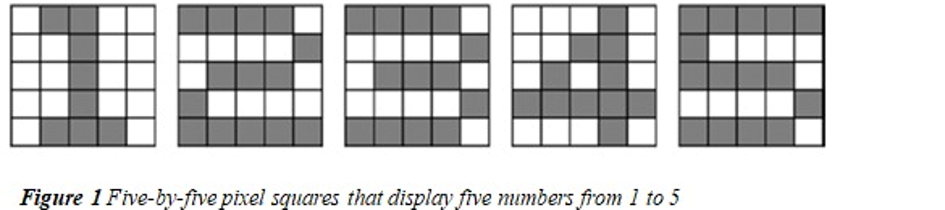!

DIGIT RECOGNITION USING ARTIFICIAL NEURAL NETWORK

Recognition Results
--------------------------------------------------
Actual Digit: 1   Predicted Digit: 1
Actual Digit: 2   Predicted Digit: 2
Actual Digit: 3   Predicted Digit: 3
Actual Digit: 4   Predicted Digit: 4
Actual Digit: 5   Predicted Digit: 5

Accuracy: 100.0 %


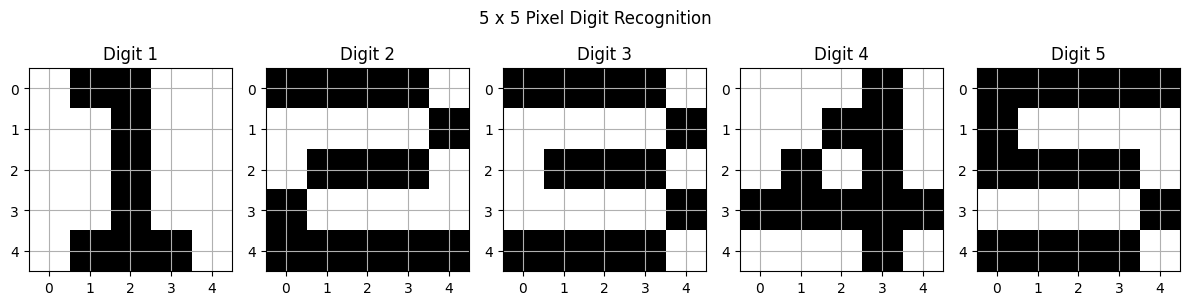

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# ==========================================================
# 5 x 5 pixel patterns of digits 1 to 5
# 1 = Black/Gray pixel
# 0 = White pixel
# ==========================================================

digit_1 = [
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0]
]

digit_2 = [
    [1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1]
]

digit_3 = [
    [1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 1, 1, 1, 0]
]

digit_4 = [
    [0, 0, 0, 1, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 1, 0]
]

digit_5 = [
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 1, 1, 1, 0]
]


# ==========================================================
# Combine all digit patterns
# ==========================================================

digits = np.array([
    digit_1,
    digit_2,
    digit_3,
    digit_4,
    digit_5
])

# Convert each 5x5 image into a 25-element vector
X = digits.reshape(5, 25)

# Target classes
y = np.array([1, 2, 3, 4, 5])


# ==========================================================
# Create Artificial Neural Network
# ==========================================================

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='lbfgs',
    max_iter=5000,
    random_state=1
)

# Train the ANN
model.fit(X, y)


# ==========================================================
# Test the trained ANN
# ==========================================================

predictions = model.predict(X)

print("=" * 50)
print("DIGIT RECOGNITION USING ARTIFICIAL NEURAL NETWORK")
print("=" * 50)

print("\nRecognition Results")
print("-" * 50)

for i in range(5):
    print("Actual Digit:", y[i],
          "  Predicted Digit:", predictions[i])

# Calculate accuracy
accuracy = model.score(X, y)

print("\nAccuracy:",
      round(accuracy * 100, 2), "%")


# ==========================================================
# Display the five 5x5 digit images
# ==========================================================

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):

    axes[i].imshow(
        digits[i],
        cmap="gray_r",
        interpolation="nearest"
    )

    axes[i].set_title("Digit " + str(i + 1))

    axes[i].set_xticks(range(5))
    axes[i].set_yticks(range(5))
    axes[i].grid(True)

plt.suptitle("5 x 5 Pixel Digit Recognition")
plt.tight_layout()
plt.show()




In [5]:
# ==========================================================
# Test a New Image
# ==========================================================

test_image = np.array([
    [1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 1, 1, 1, 0]
])

# Convert 5x5 image into 25 inputs
test_input = test_image.reshape(1, 25)

# Recognize the digit
result = model.predict(test_input)

print("\nNew Test Image:")
print(test_image)

print("\nRecognized Digit:", result[0])


New Test Image:
[[1 1 1 1 0]
 [0 0 0 0 1]
 [0 1 1 1 0]
 [0 0 0 0 1]
 [1 1 1 1 0]]

Recognized Digit: 3


### Problem05:Write a Python program to classify face/fruit/bird using Convolution Neural Network (CNN).

Found 40 files belonging to 3 classes.
Using 32 files for training.


I0000 00:00:1788545815.617375      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788545815.620483      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 40 files belonging to 3 classes.
Using 8 files for validation.
CNN IMAGE CLASSIFICATION

Classes:
['bird', 'face', 'fruit']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


Training CNN...
Epoch 1/10


2026-09-04 18:17:02.018930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-04 18:17:02.166901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3438 - loss: 1.0962

I0000 00:00:1788545824.060793      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3438 - loss: 1.0962 - val_accuracy: 0.1250 - val_loss: 3.8063
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4062 - loss: 2.4633 - val_accuracy: 0.6250 - val_loss: 0.9263
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5312 - loss: 0.9762 - val_accuracy: 0.6250 - val_loss: 0.8683
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5312 - loss: 1.0835 - val_accuracy: 0.6250 - val_loss: 0.9038
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6250 - loss: 0.8618 - val_accuracy: 0.1250 - val_loss: 1.2131
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4062 - loss: 0.8120 - val_accuracy: 0.2500 - val_loss: 0.9895
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7188 - loss: 0.6651 - val_accuracy: 1.0000 - val_loss: 0.6789
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.5389 - val_accuracy: 1.0000 - val_loss: 0.5393
Epoch 9/10
1/

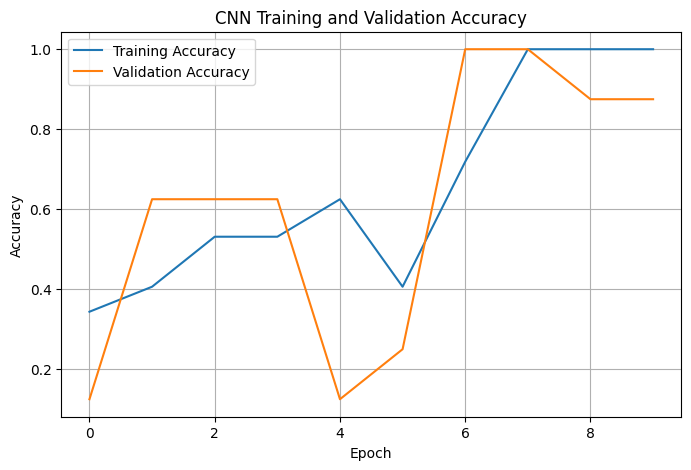

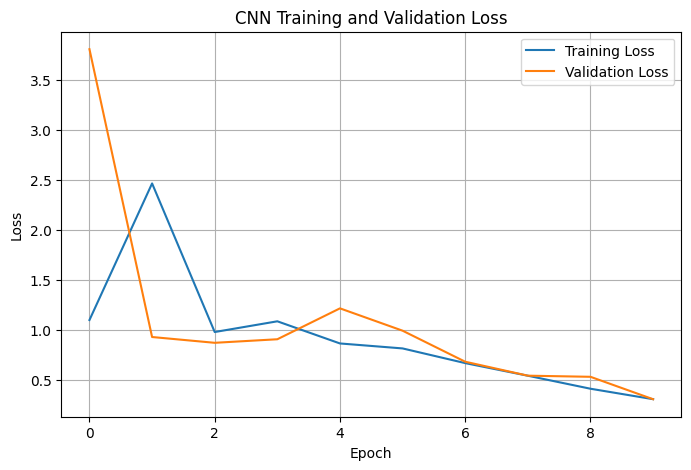

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step

IMAGE CLASSIFICATION RESULT
Predicted Class: fruit
Confidence: 84.14 %


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# CNN FOR FACE / FRUIT / BIRD CLASSIFICATION
# ============================================================

# Dataset location
dataset_path = "/kaggle/input/datasets/nomanbhuiyan/face-bird-fruit-dataset/Dataset"

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# ============================================================
# Load Training Dataset
# ============================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ============================================================
# Load Validation Dataset
# ============================================================

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Class names
class_names = train_dataset.class_names

print("=" * 60)
print("CNN IMAGE CLASSIFICATION")
print("=" * 60)

print("\nClasses:")
print(class_names)

# ============================================================
# Improve Dataset Performance
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

# ============================================================
# Build CNN Model
# ============================================================

model = tf.keras.Sequential([

    # Normalize pixel values
    tf.keras.layers.Rescaling(1.0 / 255),

    # First Convolution Layer
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    # Second Convolution Layer
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    # Third Convolution Layer
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    # Convert feature maps into vector
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output Layer
    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])

# ============================================================
# Display Model Structure
# ============================================================

model.summary()

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# Train CNN
# ============================================================

print("\nTraining CNN...")

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

# ============================================================
# Evaluate Model
# ============================================================

loss, accuracy = model.evaluate(validation_dataset)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Validation Loss:",
      round(loss, 4))

print("Validation Accuracy:",
      round(accuracy * 100, 2), "%")

# ============================================================
# Plot Training and Validation Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# Plot Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# Test One Image
# ============================================================

test_image_path = "/kaggle/input/datasets/nomanbhuiyan/face-bird-fruit-dataset/Dataset/fruit/IMG-20241220-WA0082.jpg"

if os.path.exists(test_image_path):

    # Load image
    img = tf.keras.utils.load_img(
        test_image_path,
        target_size=IMG_SIZE
    )

    # Convert image to array
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension
    img_array = tf.expand_dims(
        img_array,
        0
    )

    # Make prediction
    predictions = model.predict(img_array)

    predicted_class = np.argmax(
        predictions[0]
    )

    confidence = 100 * np.max(
        predictions[0]
    )

    print("\n" + "=" * 60)
    print("IMAGE CLASSIFICATION RESULT")
    print("=" * 60)

    print("Predicted Class:",
          class_names[predicted_class])

    print("Confidence:",
          round(confidence, 2), "%")

else:

    print("\nTest image not found.")
    print("Put a test image named 'test.jpg' in the")
    print("same folder as this Python program.")

### problem 06:Consider an artificial neural network (ANN) with three layers given below. Write a  Python program to learn this network using Back Propagation Network.

THREE-LAYER ANN USING BACKPROPAGATION

Input Values:
x1 = 0.05
x2 = 0.1

Target Values:
T1 = 0.01
T2 = 0.99

Initial Weights:
w1 = 0.15
w2 = 0.2
w3 = 0.23
w4 = 0.3
w5 = 0.4
w6 = 0.45
w7 = 0.5
w8 = 0.55

Initial Bias:
b1 = 0.35
b2 = 0.6

Training Results:
------------------------------------------------------------
Epochs = 7920

Final Hidden Layer Outputs:
H1 = 0.916732
H2 = 0.917771

Final Output Layer:
Y1 = 0.011008
Y2 = 0.989009

Target:
T1 = 0.01
T2 = 0.99

Final Error:
9.999e-07

Final Weights:
w1 = 0.200831
w2 = 0.301662
w3 = 0.279596
w4 = 0.399192
w5 = -2.311404
w6 = 2.584957
w7 = -2.221246
w8 = 2.691754

Final Bias:
b1 = 2.358543
b2 = -0.340532


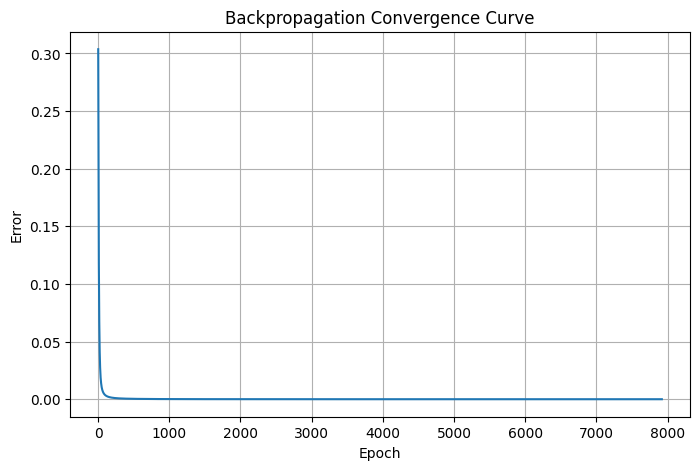

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# THREE-LAYER ANN USING BACKPROPAGATION
# ============================================================

# ------------------------------------------------------------
# Input values from the question
# ------------------------------------------------------------

x1 = 0.05
x2 = 0.10

# Target values
t1 = 0.01
t2 = 0.99


# ------------------------------------------------------------
# Initial weights from the question
# ------------------------------------------------------------

# Input -> Hidden layer
w1 = 0.15
w2 = 0.20
w3 = 0.23
w4 = 0.30

# Hidden -> Output layer
w5 = 0.40
w6 = 0.45
w7 = 0.50
w8 = 0.55


# ------------------------------------------------------------
# Bias values
# ------------------------------------------------------------

b1 = 0.35
b2 = 0.60


# ------------------------------------------------------------
# Learning rate
# ------------------------------------------------------------

learning_rate = 1.0

# Maximum number of training epochs
max_epochs = 10000

# Store error for convergence curve
error_history = []


# ============================================================
# Sigmoid Function
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# ============================================================
# BACKPROPAGATION TRAINING
# ============================================================

for epoch in range(max_epochs):

    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    # Hidden neuron H1
    net_h1 = (x1 * w1) + (x2 * w2) + b1
    h1 = sigmoid(net_h1)

    # Hidden neuron H2
    net_h2 = (x1 * w3) + (x2 * w4) + b1
    h2 = sigmoid(net_h2)


    # --------------------------------------------------------
    # Output layer
    # --------------------------------------------------------

    # Output neuron Y1
    net_y1 = (h1 * w5) + (h2 * w7) + b2
    y1 = sigmoid(net_y1)

    # Output neuron Y2
    net_y2 = (h1 * w6) + (h2 * w8) + b2
    y2 = sigmoid(net_y2)


    # --------------------------------------------------------
    # Calculate error
    # --------------------------------------------------------

    error = 0.5 * ((t1 - y1) ** 2 + (t2 - y2) ** 2)

    error_history.append(error)


    # ========================================================
    # BACKWARD PASS
    # ========================================================

    # --------------------------------------------------------
    # Output layer delta
    # --------------------------------------------------------

    delta_y1 = (t1 - y1) * y1 * (1 - y1)

    delta_y2 = (t2 - y2) * y2 * (1 - y2)


    # --------------------------------------------------------
    # Hidden layer delta
    # --------------------------------------------------------

    delta_h1 = (
        h1 * (1 - h1)
        * (delta_y1 * w5 + delta_y2 * w6)
    )

    delta_h2 = (
        h2 * (1 - h2)
        * (delta_y1 * w7 + delta_y2 * w8)
    )


    # ========================================================
    # UPDATE OUTPUT WEIGHTS
    # ========================================================

    w5 = w5 + learning_rate * delta_y1 * h1
    w6 = w6 + learning_rate * delta_y2 * h1

    w7 = w7 + learning_rate * delta_y1 * h2
    w8 = w8 + learning_rate * delta_y2 * h2


    # Update output bias
    b2 = b2 + learning_rate * (delta_y1 + delta_y2)


    # ========================================================
    # UPDATE INPUT-HIDDEN WEIGHTS
    # ========================================================

    w1 = w1 + learning_rate * delta_h1 * x1
    w2 = w2 + learning_rate * delta_h1 * x2

    w3 = w3 + learning_rate * delta_h2 * x1
    w4 = w4 + learning_rate * delta_h2 * x2


    # Update hidden bias
    b1 = b1 + learning_rate * (delta_h1 + delta_h2)


    # --------------------------------------------------------
    # Stop if error is sufficiently small
    # --------------------------------------------------------

    if error < 1e-6:
        break


# ============================================================
# FINAL FORWARD PASS
# ============================================================

net_h1 = x1 * w1 + x2 * w2 + b1
h1 = sigmoid(net_h1)

net_h2 = x1 * w3 + x2 * w4 + b1
h2 = sigmoid(net_h2)

net_y1 = h1 * w5 + h2 * w7 + b2
y1 = sigmoid(net_y1)

net_y2 = h1 * w6 + h2 * w8 + b2
y2 = sigmoid(net_y2)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("THREE-LAYER ANN USING BACKPROPAGATION")
print("=" * 60)

print("\nInput Values:")
print("x1 =", x1)
print("x2 =", x2)

print("\nTarget Values:")
print("T1 =", t1)
print("T2 =", t2)

print("\nInitial Weights:")
print("w1 =", 0.15)
print("w2 =", 0.20)
print("w3 =", 0.23)
print("w4 =", 0.30)
print("w5 =", 0.40)
print("w6 =", 0.45)
print("w7 =", 0.50)
print("w8 =", 0.55)

print("\nInitial Bias:")
print("b1 =", 0.35)
print("b2 =", 0.60)

print("\nTraining Results:")
print("-" * 60)

print("Epochs =", epoch + 1)

print("\nFinal Hidden Layer Outputs:")
print("H1 =", round(h1, 6))
print("H2 =", round(h2, 6))

print("\nFinal Output Layer:")
print("Y1 =", round(y1, 6))
print("Y2 =", round(y2, 6))

print("\nTarget:")
print("T1 =", t1)
print("T2 =", t2)

print("\nFinal Error:")
print(round(error_history[-1], 10))

print("\nFinal Weights:")
print("w1 =", round(w1, 6))
print("w2 =", round(w2, 6))
print("w3 =", round(w3, 6))
print("w4 =", round(w4, 6))
print("w5 =", round(w5, 6))
print("w6 =", round(w6, 6))
print("w7 =", round(w7, 6))
print("w8 =", round(w8, 6))

print("\nFinal Bias:")
print("b1 =", round(b1, 6))
print("b2 =", round(b2, 6))


# ============================================================
# CONVERGENCE CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(error_history) + 1),
    error_history
)

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Backpropagation Convergence Curve")
plt.grid(True)

plt.show()

### Problem 07: Use a pretrained ResNet-50 model for fine-tuning on a custom dataset (e.g., flower classification).

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

DATASET_PATH = "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("=" * 60)
print("RESNET-50 FLOWER CLASSIFICATION")
print("=" * 60)

print("\nClasses:")
print(class_names)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
RESNET-50 FLOWER CLASSIFICATION

Classes:
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [9]:
# ============================================================
# PRETRAINED RESNET-50
# ============================================================

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet-50
base_model.trainable = False


# ============================================================
# MODEL
# ============================================================

inputs = tf.keras.Input(shape=(224, 224, 3))

# ResNet-50 preprocessing
x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │     10,245 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# Learning Rate — Classification Layer Training
# প্রথমে ResNet-50-এর pretrained layers freeze করি
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# Training
print("\nTraining the new classification layer...")

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


Training the new classification layer...
Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.4450 - loss: 1.4859 - val_accuracy: 0.6744 - val_loss: 0.9479
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.6471 - loss: 0.9463 - val_accuracy: 0.7822 - val_loss: 0.6734
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.7279 - loss: 0.7333 - val_accuracy: 0.8227 - val_loss: 0.5521
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.7866 - loss: 0.6096 - val_accuracy: 0.8413 - val_loss: 0.4838
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.8043 - loss: 0.5479 - val_accuracy: 0.8494 - val_loss: 0.4395


In [12]:
# fine tuning
print("\nStarting Fine-Tuning...")

base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False


Starting Fine-Tuning...


In [13]:
#Learning Rate — Fine-Tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 47s 268ms/step - accuracy: 0.8405 - loss: 0.4471 - val_accuracy: 0.8853 - val_loss: 0.3534
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.8903 - loss: 0.3159 - val_accuracy: 0.8911 - val_loss: 0.3183
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.9181 - loss: 0.2497 - val_accuracy: 0.8957 - val_loss: 0.2989
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.9441 - loss: 0.1853 - val_accuracy: 0.9061 - val_loss: 0.2852
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.9543 - loss: 0.1516 - val_accuracy: 0.9027 - val_loss: 0.2774


In [14]:
# Evaluation
loss, accuracy = model.evaluate(validation_dataset)

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9027 - loss: 0.2774

FINAL MODEL PERFORMANCE
Validation Loss: 0.2774
Validation Accuracy: 90.27%


In [15]:
# Prediction
test_image_path = (
    "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers/rose/102501987_3cdb8e5394_n.jpg"
)

from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    test_image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("\n" + "=" * 60)
print("IMAGE PREDICTION")
print("=" * 60)

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

IMAGE PREDICTION
Predicted Class: rose
Confidence: 99.99%


### Problem-08: Train a GAN to generate synthetic handwritten digits using MNIST.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788546037.136109      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2_1/dropout_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1/20 - Generator Loss: 0.8980 - Discriminator Loss: 1.0681
Epoch 2/20 - Generator Loss: 0.8895 - Discriminator Loss: 1.2070
Epoch 3/20 - Generator Loss: 0.8715 - Discriminator Loss: 1.3045
Epoch 4/20 - Generator Loss: 0.8794 - Discriminator Loss: 1.2721
Epoch 5/20 - Generator Loss: 0.8645 - Discriminator Loss: 1.2563
Epoch 6/20 - Generator Loss: 0.8750 - Discriminator Loss: 1.2610
Epoch 7/20 - Generator Loss: 0.9167 - Discriminator Loss: 1.2451
Epoch 8/20 - Generator Loss: 1.0281 - Discriminator Loss: 1.1513
Epoch 9/20 - Generator Loss: 1.1192 - Discriminator Loss: 1.0891
Epoch 10/20 - Generator Loss: 1.1840 - Discriminator Loss: 1.0660
Epoch 11/20 - Generator Loss: 1.1661 - Discriminator Loss: 1.0555
Epoch 12/20 - Generator Loss: 1.2137 - Discriminator Loss: 1.0487
Epoch 13/20 - Generator Loss: 1.3551 - Discriminator Loss: 1.0090
Epoch 14/20 - Generator Loss: 1.2553 - Discriminator Loss: 1.0130
Epoch 15/20 - Generator Loss: 1.1954 - Discriminator Loss: 1.0739
Epoch 16/20 - Gener

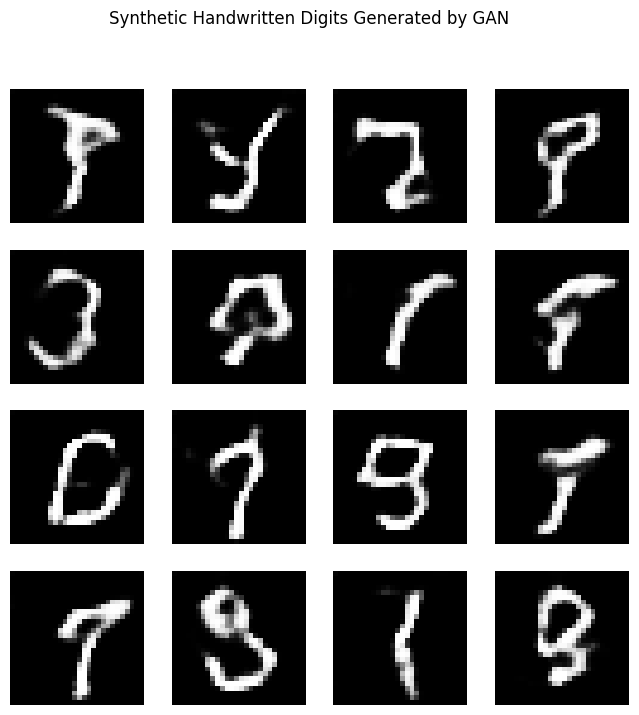

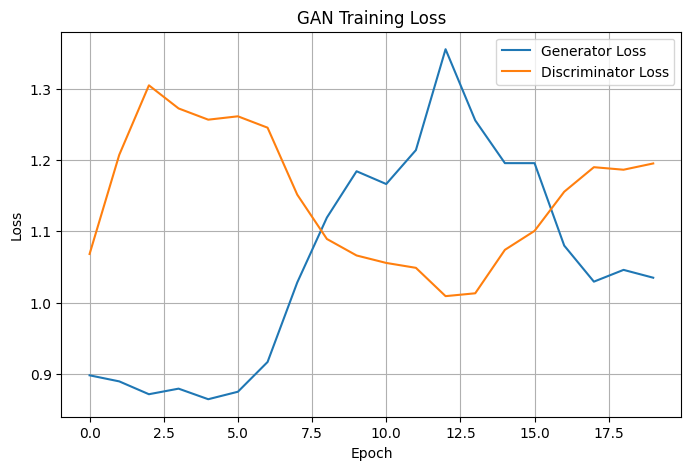

In [16]:
# MNIST dataset ব্যবহার করব, যেটা TensorFlow/Keras থেকেই automatically download করা যায়।
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ==============================
# 1. Load MNIST Dataset
# ==============================
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

# Create batches
BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


# ==============================
# 2. Build Generator
# ==============================
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7 * 7 * 256, use_bias=False,
                     input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(
            128, (5, 5), strides=(1, 1),
            padding="same", use_bias=False
        ),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(
            64, (5, 5), strides=(2, 2),
            padding="same", use_bias=False
        ),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(
            1, (5, 5), strides=(2, 2),
            padding="same", use_bias=False,
            activation="tanh"
        )
    ])

    return model


generator = build_generator()


# ==============================
# 3. Build Discriminator
# ==============================
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(
            64, (5, 5), strides=(2, 2),
            padding="same",
            input_shape=[28, 28, 1]
        ),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(
            128, (5, 5), strides=(2, 2),
            padding="same"
        ),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])

    return model


discriminator = build_discriminator()


# ==============================
# 4. Loss Functions
# ==============================
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output), real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output), fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output), fake_output
    )


# ==============================
# 5. Optimizers
# ==============================
generator_optimizer = tf.keras.optimizers.Adam(
    1e-4
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    1e-4
)


# ==============================
# 6. Training Step
# ==============================
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, 100]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise, training=True
        )

        real_output = discriminator(
            images, training=True
        )

        fake_output = discriminator(
            generated_images, training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


# ==============================
# 7. Train GAN
# ==============================
EPOCHS = 20

generator_losses = []
discriminator_losses = []

for epoch in range(EPOCHS):

    gen_loss_total = 0
    disc_loss_total = 0
    batches = 0

    for image_batch in train_dataset:

        # Last batch may be smaller than BATCH_SIZE
        if image_batch.shape[0] != BATCH_SIZE:
            continue

        gen_loss, disc_loss = train_step(image_batch)

        gen_loss_total += gen_loss.numpy()
        disc_loss_total += disc_loss.numpy()
        batches += 1

    generator_losses.append(
        gen_loss_total / batches
    )

    discriminator_losses.append(
        disc_loss_total / batches
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Generator Loss: "
        f"{generator_losses[-1]:.4f} "
        f"- Discriminator Loss: "
        f"{discriminator_losses[-1]:.4f}"
    )


# ==============================
# 8. Generate Synthetic Digits
# ==============================
noise = tf.random.normal(
    [16, 100]
)

generated_images = generator(
    noise, training=False
)

generated_images = (
    generated_images + 1
) / 2


# ==============================
# 9. Display Generated Images
# ==============================
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Synthetic Handwritten Digits Generated by GAN"
)

plt.show()


# ==============================
# 10. Plot Loss Curves
# ==============================
plt.figure(figsize=(8, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid()

plt.show()

### Problem-9: Write a  Python program to recognize the numbers 1 to 4 from speech signal using artificial neural network (ANN).

In [17]:
import os
import numpy as np
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# SPEECH NUMBER RECOGNITION USING ANN
# ============================================================

print("=" * 60)
print("SPEECH NUMBER RECOGNITION USING ANN")
print("=" * 60)

# Dataset path
BASE_PATH = "/kaggle/input/datasets/sripaadsrinivasan/audio-mnist/data"

# ------------------------------------------------------------
# Load Audio Data
# ------------------------------------------------------------

X = []
y = []

print("\nLoading speech dataset...")

# Go through speaker folders: 01, 02, 03, ...
for speaker_folder in sorted(os.listdir(BASE_PATH)):

    speaker_path = os.path.join(BASE_PATH, speaker_folder)

    if not os.path.isdir(speaker_path):
        continue

    for file_name in os.listdir(speaker_path):

        # Only WAV files
        if not file_name.lower().endswith(".wav"):
            continue

        # Example filename: 1_01_0.wav
        # First character represents the spoken digit
        digit = file_name[0]

        # We only need digits 1, 2, 3 and 4
        if digit not in ["1", "2", "3", "4"]:
            continue

        file_path = os.path.join(speaker_path, file_name)

        try:
            # Load audio
            audio, sr = librosa.load(
                file_path,
                sr=16000
            )

            # Extract 13 MFCC features
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sr,
                n_mfcc=13
            )

            # Mean and standard deviation
            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std = np.std(mfcc, axis=1)

            # Combine features
            features = np.concatenate([
                mfcc_mean,
                mfcc_std
            ])

            X.append(features)
            y.append(int(digit))

        except Exception as e:
            print("Error:", file_path)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Information")
print("-" * 40)
print("Total speech samples:", len(X))

if len(X) == 0:
    print("\nERROR: No audio files were found.")
    print("Please check the dataset path.")
    raise SystemExit

print("Number of features:", X.shape[1])
print("Classes:", sorted(np.unique(y)))

for digit in [1, 2, 3, 4]:
    print(f"Digit {digit}: {np.sum(y == digit)} samples")

# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# ANN Model
# ------------------------------------------------------------

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

print("\nTraining ANN...")
model.fit(X_train, y_train)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("ANN RESULTS")
print("=" * 60)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# Test One Speech File
# ------------------------------------------------------------

test_file = "/kaggle/input/datasets/sripaadsrinivasan/audio-mnist/data/01/1_01_0.wav"

if os.path.exists(test_file):

    audio, sr = librosa.load(
        test_file,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    test_features = np.concatenate([
        mfcc_mean,
        mfcc_std
    ]).reshape(1, -1)

    test_features = scaler.transform(test_features)

    prediction = model.predict(test_features)[0]

    probabilities = model.predict_proba(test_features)[0]

    print("\n" + "=" * 60)
    print("SINGLE SPEECH TEST")
    print("=" * 60)

    print("Test File:", test_file)
    print("Predicted Number:", prediction)
    print("Confidence:", f"{max(probabilities) * 100:.2f}%")

SPEECH NUMBER RECOGNITION USING ANN

Loading speech dataset...

Dataset Information
----------------------------------------
Total speech samples: 12000
Number of features: 26
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Digit 1: 3000 samples
Digit 2: 3000 samples
Digit 3: 3000 samples
Digit 4: 3000 samples

Training samples: 9600
Testing samples : 2400

Training ANN...

ANN RESULTS
Test Accuracy: 99.38%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       600
           2       1.00      0.98      0.99       600
           3       0.99      1.00      0.99       600
           4       1.00      0.99      1.00       600

    accuracy                           0.99      2400
   macro avg       0.99      0.99      0.99      2400
weighted avg       0.99      0.99      0.99      2400


Confusion Matrix:
[[598   0   0   2]
 [  1 591   8   0]
 [  0   1 599   0]
 [  2   1   0 597]]

SINGLE SPEECH TEST


### Problem-10: Write a Python program to Purchase Classification Prediction using SVM.

PURCHASE CLASSIFICATION USING SVM

Dataset:
------------------------------------------------------------
Age	Income	Purchase
22 	 25 	 0
25 	 30 	 0
28 	 35 	 0
30 	 40 	 0
32 	 45 	 0
35 	 50 	 0
38 	 55 	 0
40 	 60 	 1
42 	 65 	 1
45 	 70 	 1
48 	 75 	 1
50 	 80 	 1
52 	 85 	 1
55 	 90 	 1
58 	 95 	 1
60 	 100 	 1

Training samples: 12
Testing samples: 4

Training SVM...
Training completed.

CLASSIFICATION RESULTS

Test Accuracy: 75.0 %

Classification Report:
------------------------------------------------------------
               precision    recall  f1-score   support

Not Purchased       1.00      0.50      0.67         2
    Purchased       0.67      1.00      0.80         2

     accuracy                           0.75         4
    macro avg       0.83      0.75      0.73         4
 weighted avg       0.83      0.75      0.73         4


NEW CUSTOMER PREDICTION
Age: 45
Annual Income: 72 thousand dollars
Prediction: Will Purchase


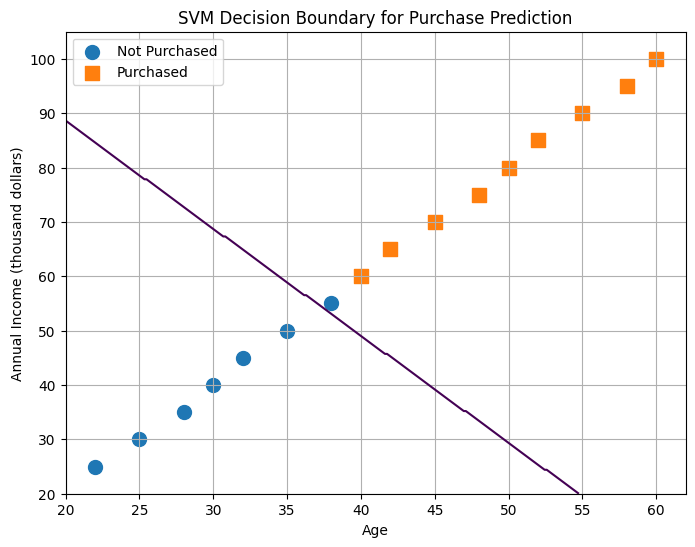

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# PURCHASE CLASSIFICATION USING SVM
# ============================================================

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
# Features:
# Column 1 = Age
# Column 2 = Annual Income (in thousand dollars)
#
# Target:
# 0 = Not Purchased
# 1 = Purchased
# ------------------------------------------------------------

X = np.array([
    [22, 25],
    [25, 30],
    [28, 35],
    [30, 40],
    [32, 45],
    [35, 50],
    [38, 55],
    [40, 60],
    [42, 65],
    [45, 70],
    [48, 75],
    [50, 80],
    [52, 85],
    [55, 90],
    [58, 95],
    [60, 100]
])

# Purchase decision
y = np.array([
    0, 0, 0, 0,
    0, 0, 0, 1,
    1, 1, 1, 1,
    1, 1, 1, 1
])


# ============================================================
# Display Dataset
# ============================================================

print("=" * 60)
print("PURCHASE CLASSIFICATION USING SVM")
print("=" * 60)

print("\nDataset:")
print("-" * 60)

print("Age\tIncome\tPurchase")

for i in range(len(X)):
    print(
        X[i, 0],
        "\t",
        X[i, 1],
        "\t",
        y[i]
    )


# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# Create SVM Model
# ============================================================

model = SVC(
    kernel="linear",
    C=1.0
)


# ============================================================
# Train SVM
# ============================================================

print("\nTraining SVM...")

model.fit(
    X_train_scaled,
    y_train
)

print("Training completed.")


# ============================================================
# Prediction
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS")
print("=" * 60)

print(
    "\nTest Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report:")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Purchased",
            "Purchased"
        ]
    )
)


# ============================================================
# Test a New Customer
# ============================================================

new_customer = np.array([
    [45, 72]
])

# Scale new data
new_customer_scaled = scaler.transform(
    new_customer
)

# Prediction
prediction = model.predict(
    new_customer_scaled
)

print("\n" + "=" * 60)
print("NEW CUSTOMER PREDICTION")
print("=" * 60)

print("Age:", new_customer[0][0])
print("Annual Income:", new_customer[0][1], "thousand dollars")

if prediction[0] == 1:
    print("Prediction: Will Purchase")
else:
    print("Prediction: Will Not Purchase")


# ============================================================
# Decision Boundary Visualization
# ============================================================

plt.figure(figsize=(8, 6))

# Plot original data
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker="o",
    s=100,
    label="Not Purchased"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker="s",
    s=100,
    label="Purchased"
)


# ------------------------------------------------------------
# Create decision boundary
# ------------------------------------------------------------

x_min = X[:, 0].min() - 2
x_max = X[:, 0].max() + 2

y_min = X[:, 1].min() - 5
y_max = X[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_scaled = scaler.transform(
    grid
)

Z = model.predict(
    grid_scaled
)

Z = Z.reshape(
    xx.shape
)


# Decision boundary
plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5]
)

plt.xlabel("Age")
plt.ylabel("Annual Income (thousand dollars)")

plt.title(
    "SVM Decision Boundary for Purchase Prediction"
)

plt.legend()
plt.grid(True)

plt.show()

### Problem 11: Write a Python program to reduce dimensions of a dataset into a new coordinate system using PCA algorithm.

DIMENSIONALITY REDUCTION USING PCA

Original Dataset:
----------------------------------------
[2.5 2.4]
[0.5 0.7]
[2.2 2.9]
[1.9 2.2]
[3.1 3. ]
[2.3 2.7]
[2.  1.6]
[1.  1.1]
[1.5 1.6]
[1.1 0.9]

Original Number of Features: 2

PCA Result:
----------------------------------------
Sample 1 -> 1.0864
Sample 2 -> -2.3089
Sample 3 -> 1.2419
Sample 4 -> 0.3408
Sample 5 -> 2.1843
Sample 6 -> 1.1607
Sample 7 -> -0.0926
Sample 8 -> -1.4821
Sample 9 -> -0.5672
Sample 10 -> -1.5633

Reduced Number of Features: 1

Explained Variance by PC1: 96.3 %

Principal Component:
[0.70710678 0.70710678]


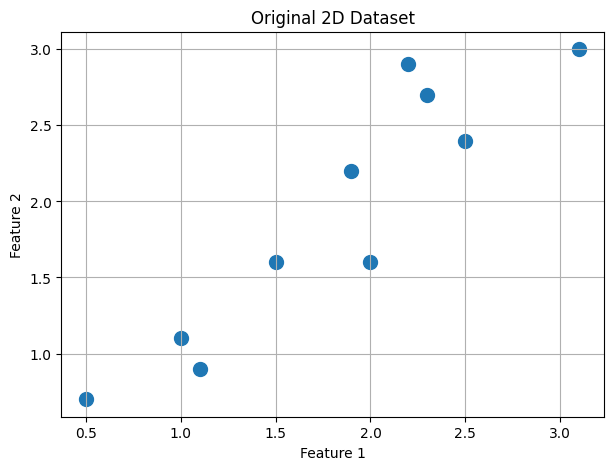

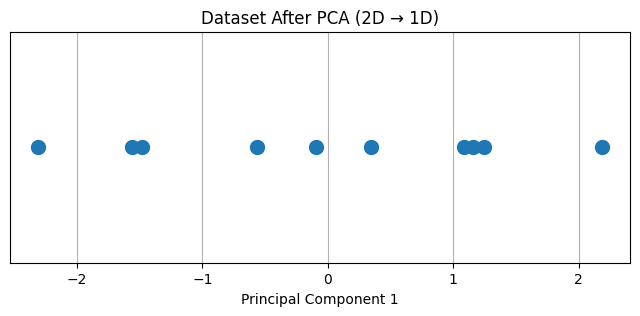


Reconstructed Approximation:
----------------------------------------
[2.382 2.527]
[0.594 0.599]
[2.464 2.615]
[1.99  2.104]
[2.961 3.15 ]
[2.421 2.569]
[1.761 1.857]
[1.029 1.068]
[1.511 1.588]
[0.987 1.022]

PCA Dimensionality Reduction Completed.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# PCA - DIMENSIONALITY REDUCTION
# ============================================================

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])


print("=" * 60)
print("DIMENSIONALITY REDUCTION USING PCA")
print("=" * 60)


# ============================================================
# Display Original Dataset
# ============================================================

print("\nOriginal Dataset:")
print("-" * 40)

for row in X:
    print(row)


print("\nOriginal Number of Features:",
      X.shape[1])


# ============================================================
# Standardize the Data
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# Apply PCA
# Reduce 2 Dimensions -> 1 Dimension
# ============================================================

pca = PCA(
    n_components=1
)

X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# Display PCA Results
# ============================================================

print("\nPCA Result:")
print("-" * 40)

for i, value in enumerate(X_pca):
    print(
        "Sample",
        i + 1,
        "->",
        round(value[0], 4)
    )


print("\nReduced Number of Features:",
      X_pca.shape[1])


# ============================================================
# Explained Variance
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_[0] * 100
)

print(
    "\nExplained Variance by PC1:",
    round(explained_variance, 2),
    "%"
)


# ============================================================
# Principal Component
# ============================================================

print("\nPrincipal Component:")
print(
    pca.components_[0]
)


# ============================================================
# Plot Original Data
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=100
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Original 2D Dataset"
)

plt.grid(True)

plt.show()


# ============================================================
# Plot Reduced Data
# ============================================================

plt.figure(figsize=(8, 3))

plt.scatter(
    X_pca[:, 0],
    np.zeros(len(X_pca)),
    s=100
)

plt.xlabel("Principal Component 1")
plt.yticks([])

plt.title(
    "Dataset After PCA (2D → 1D)"
)

plt.grid(True)

plt.show()


# ============================================================
# Reconstruct Data
# ============================================================

X_reconstructed = pca.inverse_transform(
    X_pca
)

X_reconstructed = scaler.inverse_transform(
    X_reconstructed
)


print("\nReconstructed Approximation:")
print("-" * 40)

for row in X_reconstructed:
    print(
        np.round(row, 3)
    )


print("\nPCA Dimensionality Reduction Completed.")

DIMENSIONALITY REDUCTION USING PCA

Original Dataset:
---------------------------------------------
Dataset Name: Iris Dataset
Number of Samples: 150
Original Number of Features: 4

Original Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

First 5 Samples:
[5.1 3.5 1.4 0.2]
[4.9 3.  1.4 0.2]
[4.7 3.2 1.3 0.2]
[4.6 3.1 1.5 0.2]
[5.  3.6 1.4 0.2]

PCA RESULT

Original Number of Features: 4
Reduced Number of Features: 1

Dimensionality Reduction: 4 Dimensions -> 1 Dimension

PCA Transformed Values:
---------------------------------------------
Sample 1 -> PC1 = -2.2647
Sample 2 -> PC1 = -2.081
Sample 3 -> PC1 = -2.3642
Sample 4 -> PC1 = -2.2994
Sample 5 -> PC1 = -2.3898
Sample 6 -> PC1 = -2.0756
Sample 7 -> PC1 = -2.444
Sample 8 -> PC1 = -2.2328
Sample 9 -> PC1 = -2.3346
Sample 10 -> PC1 = -2.1843

Explained Variance:
---------------------------------------------
PC1: 72.96 %

Principal Component 1:
---------------------------------------------
[ 0.

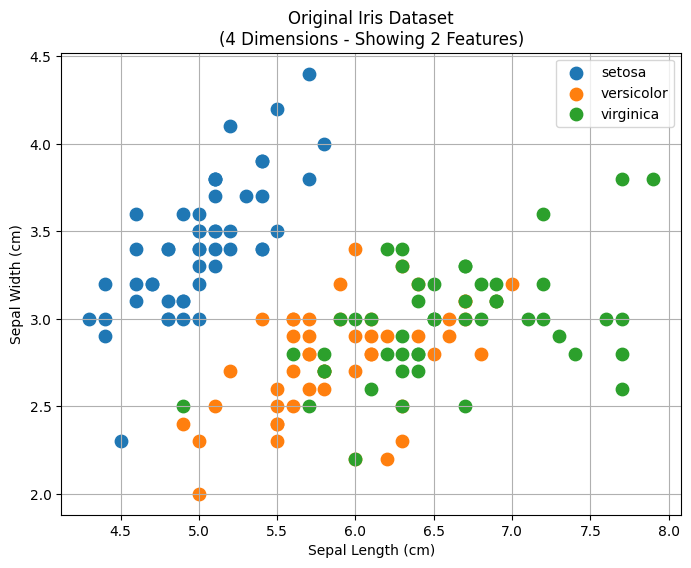

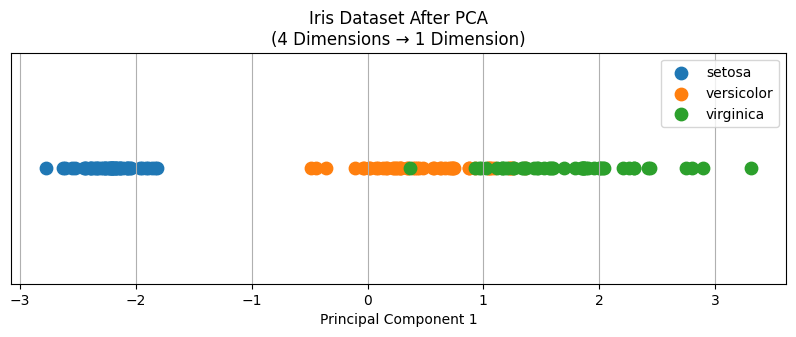

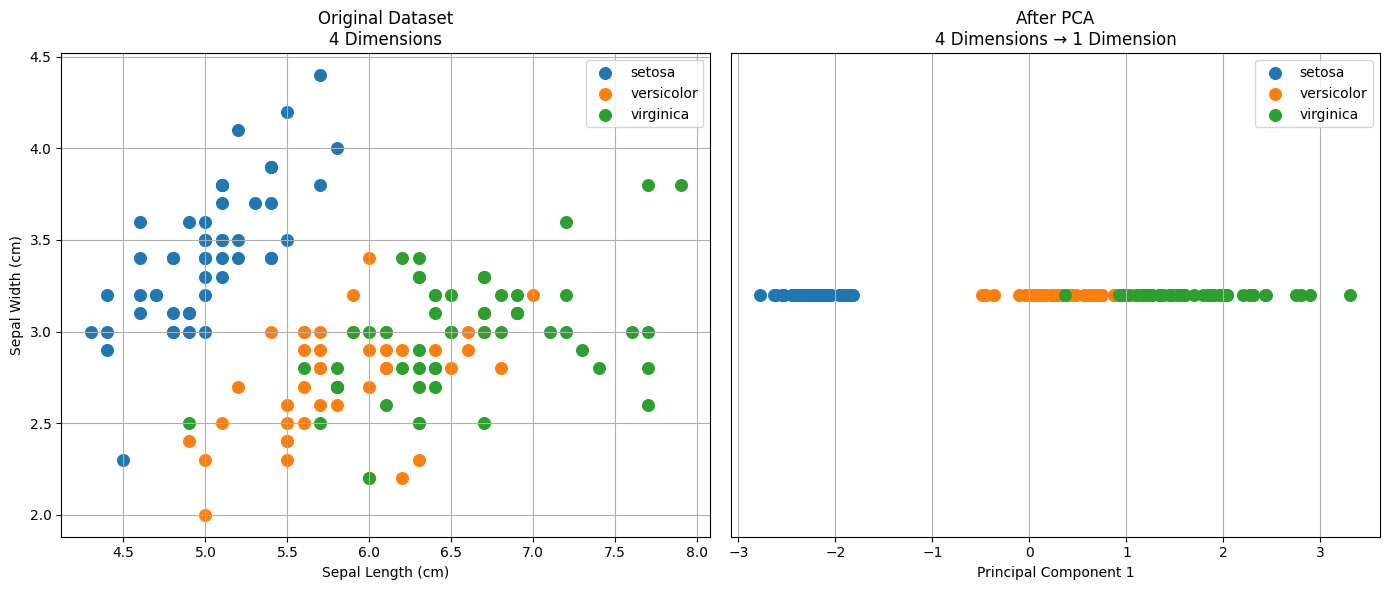


RECONSTRUCTED APPROXIMATION

First 5 Reconstructed Samples:
[4.869 3.322 1.445 0.228]
[4.948 3.301 1.633 0.306]
[4.827 3.334 1.344 0.185]
[4.855 3.326 1.41  0.213]
[4.816 3.337 1.318 0.174]

PCA Dimensionality Reduction Completed Successfully.
Original: 4 Features
Reduced: 1 Principal Component
Variance Retained: 72.96%


In [20]:
# Problem-11 solved by Iris dataset
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# PCA - DIMENSIONALITY REDUCTION
# ============================================================

print("=" * 65)
print("DIMENSIONALITY REDUCTION USING PCA")
print("=" * 65)


# ============================================================
# Load Iris Dataset
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


# ============================================================
# Display Original Dataset
# ============================================================

print("\nOriginal Dataset:")
print("-" * 45)

print("Dataset Name: Iris Dataset")

print("Number of Samples:",
      X.shape[0])

print("Original Number of Features:",
      X.shape[1])


print("\nOriginal Features:")

for feature in feature_names:
    print("-", feature)


print("\nFirst 5 Samples:")

for row in X[:5]:
    print(np.round(row, 2))


# ============================================================
# Standardize the Data
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# Apply PCA
# Reduce 4 Dimensions -> 1 Dimension
# ============================================================

pca = PCA(
    n_components=1
)

X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# Display PCA Results
# ============================================================

print("\n" + "=" * 65)
print("PCA RESULT")
print("=" * 65)


print("\nOriginal Number of Features:",
      X.shape[1])

print("Reduced Number of Features:",
      X_pca.shape[1])


print(
    "\nDimensionality Reduction:",
    X.shape[1],
    "Dimensions ->",
    X_pca.shape[1],
    "Dimension"
)


# ============================================================
# Display PCA Transformed Values
# ============================================================

print("\nPCA Transformed Values:")
print("-" * 45)

for i, value in enumerate(X_pca[:10]):

    print(
        "Sample",
        i + 1,
        "-> PC1 =",
        round(value[0], 4)
    )


# ============================================================
# Explained Variance
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_[0] * 100
)


print("\nExplained Variance:")
print("-" * 45)

print(
    "PC1:",
    round(explained_variance, 2),
    "%"
)


# ============================================================
# Principal Component
# ============================================================

print("\nPrincipal Component 1:")
print("-" * 45)

print(
    np.round(
        pca.components_[0],
        4
    )
)


# ============================================================
# Plot 1 - Original Dataset
# ============================================================

plt.figure(figsize=(8, 6))


for i, name in enumerate(target_names):

    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        s=80,
        label=name
    )


plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.title(
    "Original Iris Dataset\n"
    "(4 Dimensions - Showing 2 Features)"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Plot 2 - Dataset After PCA
# 4D -> 1D
# ============================================================

plt.figure(figsize=(10, 3))


for i, name in enumerate(target_names):

    plt.scatter(
        X_pca[y == i, 0],
        np.zeros(
            len(X_pca[y == i])
        ),
        s=80,
        label=name
    )


plt.xlabel("Principal Component 1")

plt.yticks([])

plt.title(
    "Iris Dataset After PCA\n"
    "(4 Dimensions → 1 Dimension)"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Combined Plot - Original vs PCA
# ============================================================

plt.figure(figsize=(14, 6))


# ------------------------------------------------------------
# Original Dataset
# ------------------------------------------------------------

plt.subplot(1, 2, 1)


for i, name in enumerate(target_names):

    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        s=70,
        label=name
    )


plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.title(
    "Original Dataset\n"
    "4 Dimensions"
)

plt.legend()

plt.grid(True)


# ------------------------------------------------------------
# PCA Reduced Dataset
# ------------------------------------------------------------

plt.subplot(1, 2, 2)


for i, name in enumerate(target_names):

    plt.scatter(
        X_pca[y == i, 0],
        np.zeros(
            len(X_pca[y == i])
        ),
        s=70,
        label=name
    )


plt.xlabel("Principal Component 1")

plt.yticks([])

plt.title(
    "After PCA\n"
    "4 Dimensions → 1 Dimension"
)

plt.legend()

plt.grid(True)


plt.tight_layout()

plt.show()


# ============================================================
# Reconstruct Data
# ============================================================

X_reconstructed = pca.inverse_transform(
    X_pca
)

X_reconstructed = scaler.inverse_transform(
    X_reconstructed
)


# ============================================================
# Display Reconstructed Approximation
# ============================================================

print("\n" + "=" * 65)
print("RECONSTRUCTED APPROXIMATION")
print("=" * 65)


print("\nFirst 5 Reconstructed Samples:")

for row in X_reconstructed[:5]:

    print(
        np.round(row, 3)
    )


# ============================================================
# Final Output
# ============================================================

print("\n" + "=" * 65)

print(
    "PCA Dimensionality Reduction Completed Successfully."
)

print(
    "Original: 4 Features"
)

print(
    "Reduced: 1 Principal Component"
)

print(
    f"Variance Retained: {explained_variance:.2f}%"
)

print("=" * 65)